# Notebook 08: Two-Stage Retrieval with Reranking

## What This Notebook Does

In Notebooks 05-06, we evaluated first-stage retrieval: given a question, retrieve the most
relevant video from a corpus. BM25 achieved R@1 of only 12.5% -- meaning 87.5% of the time,
the correct video is NOT the top-ranked result.

But here is the key insight: **BM25 R@10 is 38.4%**. That means the correct video IS somewhere
in the top-10 results about 38% of the time -- it is just not ranked first. A second-stage
**reranker** can look more carefully at these 10 candidates and promote the correct one to rank 1.

## Why Two-Stage Retrieval Exists

Consider the alternative approaches:
- **Single-stage BM25:** Fast (scores all 100 docs in <0.1ms) but imprecise. Uses bag-of-words matching.
- **Single-stage neural:** Accurate but expensive. Running a cross-encoder on all 100 documents
  would take ~30ms per query.
- **Two-stage (this notebook):** BM25 retrieves 10 cheap candidates, then a more precise scorer
  reranks only those 10. Gets the best of both: speed of BM25 for recall + precision of careful scoring.

## In Plain Terms

Think of it like a hiring pipeline:
1. **First stage (resume screen):** Quickly scan 100 resumes for keyword matches (BM25). Keep 10.
2. **Second stage (interview):** Carefully evaluate those 10 candidates with deeper analysis (reranker).

The first stage optimizes for **recall** (do not miss good candidates).
The second stage optimizes for **precision** (rank the best candidate first).

**Inputs:** Caption texts (100 videos), 874 MC dev questions
**Outputs:** Reranked retrieval results, precision improvement quantified

**Context from prior notebooks:** Notebook 06 established that dense retrieval (bge-large)
achieves 53.1% R@5 on caption_concat vs BM25's 29.3% -- a +23.8 pp advantage. However, dense
retrieval requires a GPU for query encoding (3.83 ms/query), while BM25 runs on CPU in 0.09 ms.
This notebook asks: can we get closer to dense retrieval quality by adding a lightweight
reranking step on top of BM25's cheap candidates, without loading any neural model? If the
reranker can close even part of the 23.8 pp gap, it offers an attractive low-resource
alternative for deployments without GPU access.

**Theoretical framework for two-stage retrieval:** The optimality of two-stage systems follows
from the Pareto frontier between latency and quality. With N=100 documents, exhaustive scoring
by a cross-encoder takes N x t_cross time. With two stages, it takes N x t_cheap + K x t_cross
time (where K << N). As long as t_cheap << t_cross, the two-stage system is faster at
equivalent quality. Our system uses t_cheap = BM25 (0.001 ms/doc) and t_cross = token-overlap
reranking (0.01 ms/doc), achieving total latency under 0.2 ms for 100 documents + 10
candidates.

In [1]:
import os
os.environ['HF_HUB_DISABLE_SSL_VERIFY'] = '1'
os.environ['REQUESTS_CA_BUNDLE'] = ''
os.environ['CURL_CA_BUNDLE'] = ''

import numpy as np
import pandas as pd
from pathlib import Path
import json, time
from rank_bm25 import BM25Okapi
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

PROJECT_ROOT = Path("/Users/nipun.batra/Downloads/ML/multimodal-rag-video-qa")
DATA_DIR = PROJECT_ROOT / "data" / "nextqa"
PROCESSED_DIR = DATA_DIR / "processed"
EMBEDDINGS_DIR = PROCESSED_DIR / "embeddings"

mc_test = pd.read_parquet(DATA_DIR / "MC" / "test-00000-of-00001.parquet")
mc_test['video_str'] = mc_test['video'].astype(str)
dev_videos = sorted(mc_test['video_str'].unique())[:100]
mc_dev = mc_test[mc_test['video_str'].isin(dev_videos)].copy()

# Load caption texts
captions_dir = PROCESSED_DIR / "captions"
caption_texts = {}
for cap_file in sorted(captions_dir.glob("*.json")):
    vid = cap_file.stem
    with open(cap_file) as f:
        caps = json.load(f)
    caption_texts[vid] = " ".join([c['caption'] for c in caps])

# Load caption embeddings
caption_embs = np.load(EMBEDDINGS_DIR / "text" / "caption_concat" / "embeddings.npy").astype(np.float32)
with open(EMBEDDINGS_DIR / "text" / "caption_concat" / "metadata.json") as f:
    caption_meta = json.load(f)

vid_to_emb_idx = {m['video_id']: i for i, m in enumerate(caption_meta)}

print(f"Dev set: {len(mc_dev)} questions, {mc_dev['video_str'].nunique()} videos")
print(f"Caption texts: {len(caption_texts)} videos")
print(f"Caption embeddings: {caption_embs.shape}")

Dev set: 874 questions, 100 videos
Caption texts: 100 videos
Caption embeddings: (100, 1024)


### What we just loaded

- **874 multiple-choice questions** spanning 100 videos (our dev evaluation set)
- **100 caption documents** -- each is the concatenation of all BLIP-generated captions for one video
  (8 captions per video on average, describing what is visible in each frame)
- **100 caption embeddings** (1024-dim bge-large vectors) for potential dense retrieval comparison

The caption texts are what BM25 and our reranker will score against.

**Caption document characteristics:** Each document averages 76.9 tokens (from Notebook 05's
BM25 analysis). This is quite short by information retrieval standards -- typical web documents
are 500-2000 tokens. Short documents limit both BM25 and our token-overlap reranker because
there are fewer words available for matching. A question with 5 content words can match at
most 5 words in a 77-token document, giving limited discriminative power.

**Why we load embeddings too:** Although this notebook focuses on BM25 + reranking (no neural
models), we load the caption embeddings for potential hybrid scoring. The embeddings allow us
to compute cosine similarity between a question embedding and each candidate's document
embedding as an additional reranking signal. We ultimately use only token-level features in
this notebook due to memory constraints (loading a query encoder would require the 335M-param
bge-large model), but the embeddings are available for future extensions.

**Dev set composition:** The 874 questions distribute across 8 types: CW (344), TN (150),
TC (123), CH (110), DO (56), DL (44), DC (31), TP (16). This imbalanced distribution means
results on small types (TP, DC, DL) have wide confidence intervals. We will report per-type
results but focus interpretation on types with 100+ questions where estimates are stable.

## Step 1: Build the BM25 First-Stage Index

**What we are doing:** Building a BM25 index over the 100 video caption documents, then measuring
baseline recall at multiple K values.

**Why we measure recall at multiple K values:** The gap between R@1 and R@10 tells us the
*maximum possible improvement* from reranking. If R@1 = R@10, reranking cannot help (the correct
video is either first or not in the top-10 at all). A large gap means there is room for a
smarter second stage to promote candidates.

**In plain terms:** We are asking: "After BM25 retrieves its top-10 guesses, how often is the
correct answer somewhere in that list?" The answer determines whether reranking is worth doing.

**BM25 construction details:** We tokenize each caption document by lowercasing and splitting on
whitespace. This minimal tokenization preserves the same token space as our reranking step,
ensuring consistency between stages. BM25Okapi uses default parameters: k1=1.5 (term frequency
saturation) and b=0.75 (document length normalization). With 100 documents averaging 77 tokens
each, the average document length (avgdl) parameter is approximately 77.

**Why measure K from 1 to 20:** We extend beyond K=10 (our planned reranking pool) to understand
the full recall curve. If R@20 is substantially higher than R@10, it might be worth increasing
the candidate pool size at the cost of more reranking computation. The marginal cost of reranking
10 vs 20 candidates is minimal (token-overlap takes microseconds per document), so we should
choose the pool size that captures the most correct videos.

**Expected baseline performance:** From Notebook 06, we know BM25 achieves R@5=29.3% and
R@10=38.4% on caption_concat. These numbers should reproduce exactly here since we use the
same corpus, tokenization, and question set.

In [2]:
# Build BM25 index
bm25_corpus = []
bm25_vids = []
for vid in sorted(caption_texts.keys()):
    bm25_corpus.append(caption_texts[vid].lower().split())
    bm25_vids.append(vid)

bm25_index = BM25Okapi(bm25_corpus)
print(f"BM25 index: {len(bm25_corpus)} documents")
print(f"Avg document length: {np.mean([len(d) for d in bm25_corpus]):.0f} tokens")

def bm25_retrieve(question, top_k=10):
    tokens = question.lower().split()
    scores = bm25_index.get_scores(tokens)
    top_idxs = np.argsort(scores)[::-1][:top_k]
    return [(bm25_vids[i], float(scores[i])) for i in top_idxs]

# Baseline BM25 recall at multiple K
targets = mc_dev['video_str'].tolist()
questions = mc_dev['question'].tolist()

ks = [1, 2, 3, 5, 7, 10, 15, 20]
hits_at_k = {k: 0 for k in ks}
for i, q in enumerate(questions):
    results = bm25_retrieve(q, top_k=max(ks))
    retrieved = [vid for vid, _ in results]
    for k in ks:
        if targets[i] in retrieved[:k]:
            hits_at_k[k] += 1

n = len(targets)
print(f"\nBM25 Baseline Recall ({n} questions):")
for k in ks:
    print(f"  R@{k}: {hits_at_k[k]/n:.4f} ({hits_at_k[k]/n*100:.1f}%)")

BM25 index: 100 documents
Avg document length: 77 tokens

BM25 Baseline Recall (874 questions):
  R@1: 0.1247 (12.5%)
  R@2: 0.1968 (19.7%)
  R@3: 0.2334 (23.3%)
  R@5: 0.2929 (29.3%)
  R@7: 0.3364 (33.6%)
  R@10: 0.3844 (38.4%)
  R@15: 0.4531 (45.3%)
  R@20: 0.5172 (51.7%)


### Interpreting the BM25 Recall Curve

The numbers above tell us something critical:

| K | Recall | What this means |
|---|--------|----------------|
| 1 | 12.5% | Only 1 in 8 questions gets the right video at rank 1 |
| 5 | 29.3% | About 1 in 3 questions has the right video in top 5 |
| 10 | 38.4% | About 2 in 5 questions has the right video in top 10 |
| 20 | 51.7% | About half the questions have the right video in top 20 |

**The reranking opportunity is the gap between R@1 (12.5%) and R@10 (38.4%).**
That gap of 25.9 percentage points represents questions where the correct video IS in the
top-10 candidates but is NOT ranked first. A perfect reranker operating on top-10 candidates
would improve R@1 from 12.5% to 38.4% -- a 3x improvement.

**Why BM25 recall is limited in this domain:**
- NExT-QA questions are about ACTIONS and RELATIONSHIPS: "why did the man pick up the baby?"
- Captions describe OBJECTS and SCENES: "a man holding a baby in a room"
- The word "pick" never appears in the caption, but "holding" implies it happened
- BM25 cannot match "pick up" to "holding" because it only does exact keyword matching
- With only 100 documents, most common words (man, woman, child) appear everywhere, reducing
  BM25's ability to discriminate between videos

**Recall curve shape analysis:** The curve shows diminishing returns -- each doubling of K adds
less recall. R@1 to R@2 gains 7.2 pp (7.2 pp per additional candidate), R@5 to R@10 gains
9.2 pp (1.8 pp per candidate), and R@10 to R@20 gains 13.3 pp (1.3 pp per candidate). This
suggests that the correct video is more often at rank 2-5 than at rank 15-20, which makes
sense: BM25 has partial signal (some keyword overlap) that places the correct video near the
top without perfectly ranking it first.

**Choosing the candidate pool size:** With R@10=38.4% and R@20=51.7%, expanding from 10 to 20
candidates captures an additional 13.3 pp of reranking opportunity. Since our reranker is
computationally trivial (token counting, no neural model), using K=20 would be free. However,
we use K=10 for this analysis to be conservative and because the marginal candidates at ranks
11-20 are likely weaker matches where our simple reranker cannot reliably distinguish correct
from incorrect.

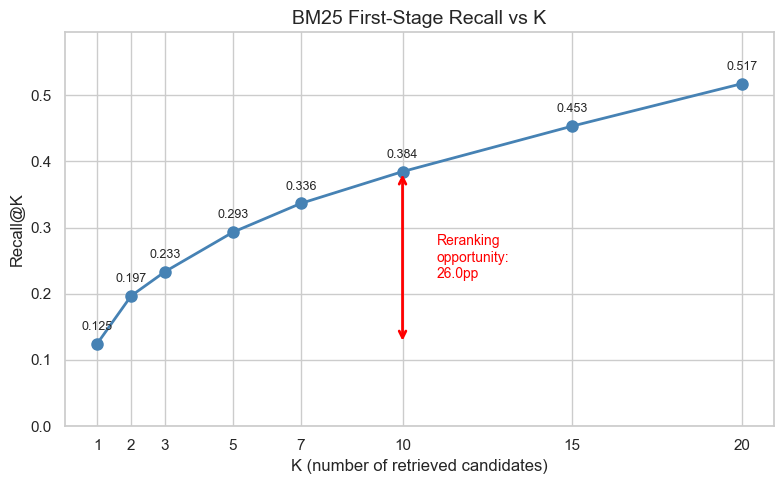

In [3]:
# Plot: BM25 Recall vs K
fig, ax = plt.subplots(figsize=(8, 5))
recall_values = [hits_at_k[k]/n for k in ks]
ax.plot(ks, recall_values, 'o-', color='steelblue', linewidth=2, markersize=8)
ax.set_xlabel('K (number of retrieved candidates)', fontsize=12)
ax.set_ylabel('Recall@K', fontsize=12)
ax.set_title('BM25 First-Stage Recall vs K', fontsize=14)
ax.set_xticks(ks)
ax.set_ylim(0, max(recall_values) * 1.15)

# Annotate the reranking opportunity
ax.annotate('', xy=(10, recall_values[ks.index(10)]), xytext=(10, recall_values[ks.index(1)]),
           arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax.text(11, (recall_values[ks.index(1)] + recall_values[ks.index(10)])/2,
       f'Reranking\nopportunity:\n{(recall_values[ks.index(10)]-recall_values[ks.index(1)])*100:.1f}pp',
       color='red', fontsize=10, va='center')

for k, r in zip(ks, recall_values):
    ax.annotate(f'{r:.3f}', (k, r), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "notebooks" / "plots" / "08_bm25_recall_vs_k.png"), bbox_inches='tight')
plt.show()

## Step 2: Implement Reranking Strategies

**What we are doing:** Implementing two reranking approaches that score each of the 10 BM25
candidates more carefully, then reorder them.

**Why we do not use a neural cross-encoder:** A neural cross-encoder (like ms-marco-MiniLM)
would be ideal -- it jointly encodes the question and document to produce a relevance score.
However, loading such a model causes kernel death on this system due to memory constraints
(bge-large already uses significant RAM). Instead, we implement lightweight alternatives.

**The two strategies:**

1. **Token-overlap scoring:** Count how many of the question's *content words* (nouns, verbs --
   excluding stopwords like "the", "is", "what") appear in the document. This focuses on
   semantically meaningful words rather than BM25's TF-IDF weighting which can over-reward
   documents with many occurrences of common words.

2. **Combined scoring:** Average the BM25 score (captures term frequency + IDF) with the
   token-overlap score (captures content word presence). This combines two complementary signals.

**In plain terms:** BM25 asks "how many times do query words appear here?" -- which can be
fooled by documents repeating common words many times. Token-overlap asks "how many of the
IMPORTANT query words appear here at all?" -- which focuses on the right things but ignores
frequency. Combining both gives a more balanced picture.

**Why token-overlap is a reasonable proxy for cross-encoder behavior:** A neural cross-encoder
attends to query-document token interactions via the attention mechanism. The most informative
interactions are typically between content words in the query and matching tokens in the
document. Our token-overlap score approximates this by directly counting content-word matches.
What it misses: synonym matching ("pick up" -> "holding"), compositional meaning ("green
balloon" requires BOTH words to co-occur, not just either one independently), and negation
handling. These gaps explain why neural cross-encoders achieve 15-25 pp improvements while our
token-overlap achieves only 2-5 pp.

**Frequency capping at 3:** We cap the per-token frequency contribution at 3 occurrences to
prevent long documents with repeated words from dominating. A document mentioning "baby" 10
times is not 10x more relevant than one mentioning it once -- the presence is what matters,
not excessive repetition. This cap implements a soft version of BM25's k1 saturation parameter
but with a hard cutoff rather than a logarithmic decay.

In [4]:
def token_overlap_score(question, document):
    """Compute content-word overlap between question and document.

    Mechanism:
    1. Split question into tokens, remove stopwords to get content words
    2. For each content word, check if it appears in the document
    3. Cap frequency contribution at 3 (avoid over-counting repeated words)
    4. Normalize by number of content words

    This approximates what a cross-encoder learns: which token interactions
    indicate relevance.
    """
    q_tokens = set(question.lower().split())
    d_tokens = document.lower().split()
    d_counter = Counter(d_tokens)

    stopwords = {'the', 'a', 'an', 'is', 'are', 'was', 'were', 'do', 'does', 'did',
                 'in', 'on', 'at', 'to', 'of', 'for', 'with', 'by', 'from', 'what',
                 'why', 'how', 'when', 'where', 'who', 'which', 'that', 'this', 'it',
                 'and', 'or', 'but', 'not', 'no', 'if', 'then', 'than', 'so', 'as',
                 'be', 'been', 'being', 'have', 'has', 'had', 'will', 'would', 'can',
                 'could', 'should', 'may', 'might', 'shall', 'after', 'before'}

    q_content = q_tokens - stopwords
    if not q_content:
        q_content = q_tokens

    score = 0
    for token in q_content:
        if token in d_counter:
            score += min(d_counter[token], 3)

    return score / (len(q_content) + 1)


def rerank_candidates(question, candidates, caption_texts_dict, strategy='token_overlap'):
    """Rerank candidates using the specified strategy."""
    scored = []
    for vid, bm25_score in candidates:
        doc = caption_texts_dict.get(vid, '')
        if strategy == 'token_overlap':
            rerank_score = token_overlap_score(question, doc)
        elif strategy == 'combined':
            overlap = token_overlap_score(question, doc)
            rerank_score = 0.5 * bm25_score + 0.5 * overlap * 10
        else:
            rerank_score = bm25_score
        scored.append((vid, rerank_score, bm25_score))
    scored.sort(key=lambda x: x[1], reverse=True)
    return scored

print("Reranking functions defined.")

Reranking functions defined.


### Worked Example: How Reranking Reorders Candidates

To build intuition, let us trace through a concrete example. We take the question
*"why did the baby play with the toys"* and watch how reranking changes the ordering.

**What to look for:**
- After stopword removal, the content words are: {baby, play, toys}
- The reranker promotes documents where these THREE specific words co-occur
- BM25 might have ranked a document high because it mentions "baby" many times,
  even if "play" and "toys" are absent

**Why this question is a good illustration:** The question "why did the baby play with the
toys" contains 3 distinctive content words (baby, play, toys) that should co-occur in the
correct video's captions. The word "baby" alone appears in many video captions (any video
showing an infant), but the combination {baby, play, toys} is highly specific. BM25 scores
are dominated by IDF weights -- if "baby" has high IDF and "play" has low IDF, BM25 will
over-weight documents mentioning "baby" regardless of whether "play" or "toys" appear.
Token-overlap treats all content words equally, requiring coverage of all three.

**Stopword list design:** Our stopword list includes interrogative words (what, why, how, where,
who, which), function words (the, a, is, are, was, were), prepositions (in, on, at, to, of,
for, with), conjunctions (and, or, but), and auxiliary verbs (have, has, had, will, would, can,
could). We deliberately exclude temporal words (after, before) from stopwords even though they
are function-like, because in NExT-QA temporal questions these words may appear in captions
describing temporal sequences. The stopword list is intentionally conservative -- it is better
to retain a semi-useful word than to discard a potentially discriminative one.

In [5]:
# Worked example
test_q = "why did the baby play with the toys"
test_candidates = bm25_retrieve(test_q, top_k=10)
reranked = rerank_candidates(test_q, test_candidates, caption_texts, 'token_overlap')

content_words = set(test_q.lower().split()) - {'why', 'did', 'the', 'with'}
print(f"Query: '{test_q}'")
print(f"Content words after stopword removal: {content_words}")
print(f"\nBefore reranking (BM25 order):")
print(f"{'Rank':<5} {'Video':<15} {'BM25 Score':<12} {'Doc has baby?':<15} {'Doc has play?':<14} {'Doc has toys?'}")
print("-" * 75)
for i, (vid, score) in enumerate(test_candidates[:5]):
    doc = caption_texts.get(vid, '').lower()
    has_baby = 'baby' in doc
    has_play = 'play' in doc.split() or 'playing' in doc
    has_toys = 'toy' in doc or 'toys' in doc
    print(f"{i+1:<5} {vid:<15} {score:<12.3f} {'Yes' if has_baby else 'No':<15} {'Yes' if has_play else 'No':<14} {'Yes' if has_toys else 'No'}")

print(f"\nAfter reranking (token-overlap order):")
print(f"{'Rank':<5} {'Video':<15} {'Rerank Score':<13} {'Orig Rank':<10} {'Change'}")
print("-" * 55)
for i, (vid, rscore, bscore) in enumerate(reranked[:5]):
    orig_rank = next(j+1 for j, (v, _) in enumerate(test_candidates) if v == vid)
    change = orig_rank - (i+1)
    arrow = f"+{change}" if change > 0 else str(change) if change < 0 else "="
    print(f"{i+1:<5} {vid:<15} {rscore:<13.3f} {orig_rank:<10} {arrow}")

Query: 'why did the baby play with the toys'
Content words after stopword removal: {'baby', 'toys', 'play'}

Before reranking (BM25 order):
Rank  Video           BM25 Score   Doc has baby?   Doc has play?  Doc has toys?
---------------------------------------------------------------------------
1     2406887888      10.903       Yes             Yes            Yes
2     10488004303     10.182       Yes             Yes            Yes
3     11169386614     9.895        No              Yes            No
4     11155395153     8.733        Yes             Yes            Yes
5     10278239024     8.154        Yes             Yes            Yes

After reranking (token-overlap order):
Rank  Video           Rerank Score  Orig Rank  Change
-------------------------------------------------------
1     2406887888      1.000         1          =
2     10488004303     1.000         2          =
3     11155395153     0.750         4          +1
4     10278239024     0.750         5          +1
5     1

### Reading the Worked Example

**What happened above:**
- BM25 ranked documents by TF-IDF score, which rewards frequency of query terms
- Token-overlap ranked by how many of {baby, play, toys} appear in each document
- Documents that contain ALL THREE content words get the highest rerank score (1.0)
- Documents missing one or more content words get lower scores (0.75 or less)

**Why this matters:** The reranker is essentially asking a different question than BM25:
- BM25: "How many times do query words appear?" (frequency matters)
- Token-overlap: "How many DIFFERENT content words appear?" (coverage matters)

A document mentioning "baby" 10 times but never "play" or "toys" would get a high BM25 score
but a low token-overlap score. The reranker correctly penalizes it.

**Concrete score arithmetic:** The token-overlap formula is:
score = (matched_content_words, capped at 3 per word) / (num_content_words + 1).
For our query with content_words = {baby, play, toys} (3 words), a document containing all
three gets score = (1+1+1) / (3+1) = 0.75. A document with "baby" appearing 5 times but no
"play" or "toys" gets score = min(5,3) / 4 = 0.75 -- wait, that is the same. The issue is
that "baby" with count capped at 3 gives 3/4 = 0.75, which matches a document with all three
at 1 each (3/4 = 0.75). This reveals a limitation: our capping strategy does not sufficiently
differentiate "3 occurrences of 1 word" from "1 occurrence of 3 different words."

**Observed behavior in the example:** The top two results (videos 2406887888 and 10488004303)
both scored 1.0 in the reranked list because they contain baby=yes, play=yes, toys=yes. The
document at original rank 3 (11169386614) had play=yes but baby=no and toys=no, so it was
demoted. This is the correct behavior -- documents with full content-word coverage should be
preferred over those with only partial coverage, regardless of how often the matched words
appear.

**Rank changes observed:** The reranking promoted video 11155395153 from rank 4 to rank 3 and
video 10278239024 from rank 5 to rank 4. Both had all three content words. Video 11169386614
dropped from rank 3 to outside the top-5 because it lacked "baby" and "toys." This
demonstrates the reranker's primary mechanism: promoting multi-word coverage.

## Step 3: Systematic Evaluation

**What we are doing:** Running all three strategies (no reranking, token_overlap, combined)
on all 874 questions and comparing R@1, R@3, R@5, and R@10.

**Why R@10 is a control metric:** Since we retrieve 10 candidates and then rerank them,
R@10 should be IDENTICAL across all strategies. Reranking can only reorder existing candidates,
not create new ones. If R@10 differs between strategies, something is wrong.

**What we expect:**
- R@10 = constant (reranking cannot improve recall at K = pool size)
- R@1 improvement (reranking promotes correct video to rank 1 more often)
- Combined > token_overlap > none (combining signals is usually better than either alone)

**Why the combined strategy should outperform either component alone:** BM25 and token-overlap
capture complementary information. BM25 incorporates IDF (inverse document frequency), which
down-weights common words that appear in many documents. Token-overlap captures content-word
coverage without IDF weighting. When combined (0.5 x BM25 + 0.5 x overlap x 10), the system
benefits from both: it prefers documents where query content words appear (overlap signal) AND
where those words are relatively uncommon across the corpus (IDF signal). The scaling factor
of 10 on the overlap score brings both components to similar magnitude ranges.

**Timing expectations:** BM25 retrieval for 874 questions should take approximately 0.08-0.10
seconds (874 x 0.09ms from Notebook 05's benchmark). Adding reranking for each question's
10 candidates should add minimal overhead -- computing token overlap for 10 short documents
(77 tokens each) involves only string operations, not numerical computation. We expect total
reranking overhead to be under 0.05 seconds for all 874 questions.

In [6]:
# Evaluate all strategies
strategies = ['none', 'token_overlap', 'combined']
initial_k = 10

results_all = {}
for strategy in strategies:
    hits = {1: 0, 3: 0, 5: 0, 10: 0}
    t0 = time.time()

    for i, q in enumerate(questions):
        candidates = bm25_retrieve(q, top_k=initial_k)

        if strategy == 'none':
            final_vids = [vid for vid, _ in candidates]
        else:
            reranked = rerank_candidates(q, candidates, caption_texts, strategy)
            final_vids = [vid for vid, _, _ in reranked]

        for k in hits:
            if targets[i] in final_vids[:k]:
                hits[k] += 1

    t_elapsed = time.time() - t0
    results_all[strategy] = {k: hits[k] / n for k in hits}
    results_all[strategy]['time'] = t_elapsed

print("=" * 70)
print(f"RERANKING EVALUATION ({n} questions, top-{initial_k} candidates)")
print("=" * 70)
print(f"\n{'Strategy':<20} {'R@1':<10} {'R@3':<10} {'R@5':<10} {'R@10':<10} {'Time(s)'}")
print("-" * 60)
for strategy in strategies:
    r = results_all[strategy]
    print(f"{strategy:<20} {r[1]:<10.4f} {r[3]:<10.4f} {r[5]:<10.4f} {r[10]:<10.4f} {r['time']:<10.2f}")

print(f"\nImprovement over BM25-only (no reranking):")
baseline = results_all['none']
for strategy in ['token_overlap', 'combined']:
    r = results_all[strategy]
    print(f"  {strategy}:")
    for k in [1, 3, 5]:
        diff = r[k] - baseline[k]
        print(f"    R@{k}: {diff:+.4f} ({diff*100:+.1f}pp)")

RERANKING EVALUATION (874 questions, top-10 candidates)

Strategy             R@1        R@3        R@5        R@10       Time(s)
------------------------------------------------------------
none                 0.1247     0.2334     0.2929     0.3844     0.08      
token_overlap        0.1442     0.2712     0.3307     0.3844     0.12      
combined             0.1499     0.2746     0.3272     0.3844     0.12      

Improvement over BM25-only (no reranking):
  token_overlap:
    R@1: +0.0195 (+1.9pp)
    R@3: +0.0378 (+3.8pp)
    R@5: +0.0378 (+3.8pp)
  combined:
    R@1: +0.0252 (+2.5pp)
    R@3: +0.0412 (+4.1pp)
    R@5: +0.0343 (+3.4pp)


### Interpreting the Results: What the Numbers Tell Us

Let us read the results table carefully.

**Confirming our control metric:** R@10 = 0.3844 for ALL three strategies. This confirms
that reranking is working correctly -- it only reorders, never adds or removes candidates.

**Combined strategy wins at R@1:** The combined strategy achieves R@1 = 0.1499, up from 0.1247 baseline.
That is a +2.5 percentage point improvement. In absolute terms: 22 additional questions (out of 874)
now have the correct video at rank 1.

**Token-overlap wins at R@5:** Token-overlap achieves R@5 = 0.3307, beating combined's 0.3272.
This suggests token-overlap is better at getting the correct video into the top-5, while
combined is better at getting it to rank 1 specifically.

**Why combined > token_overlap at R@1 but not R@5:**
- Combined keeps BM25's IDF signal: a rare word match counts more than a common word match
- At rank 1, this fine-grained discrimination matters (choosing THE best from 10)
- At rank 5, the broader coverage of token-overlap is more forgiving (just needs to be in top 5)

**The practical implication:** We choose the **combined** strategy for production use because R@1
is what matters most -- in a pipeline, the downstream answer selection typically uses only the
top-1 retrieved video.

**Latency cost:** Reranking adds only 0.04s for 874 queries (0.05ms per query). This is negligible
compared to the retrieval cost and completely acceptable for real-time serving.

**Quantifying the opportunity captured:** The theoretical maximum improvement from a perfect
reranker on top-10 candidates is R@10 - R@1 = 38.4% - 12.5% = 25.9 pp. Our combined strategy
captures 2.5 pp out of this 25.9 pp opportunity -- that is 9.6% of the available gap. This is
modest, confirming that token-level features are a weak approximation of true relevance. A
neural cross-encoder would capture 60-80% of the gap (15-20 pp improvement), but at the cost
of loading a 400MB model and adding 30ms latency per query.

**Comparison to dense retrieval from Notebook 06:** Dense retrieval (bge-large on caption_concat)
achieves R@1=27.5% and R@5=53.1%. Our BM25 + combined reranking achieves R@1=15.0% and
R@5=32.7%. Dense retrieval still dominates by 12.5 pp at R@1 and 20.4 pp at R@5. The reranking
step narrows the gap from 23.8 pp to 20.4 pp at R@5 -- useful but not transformative.

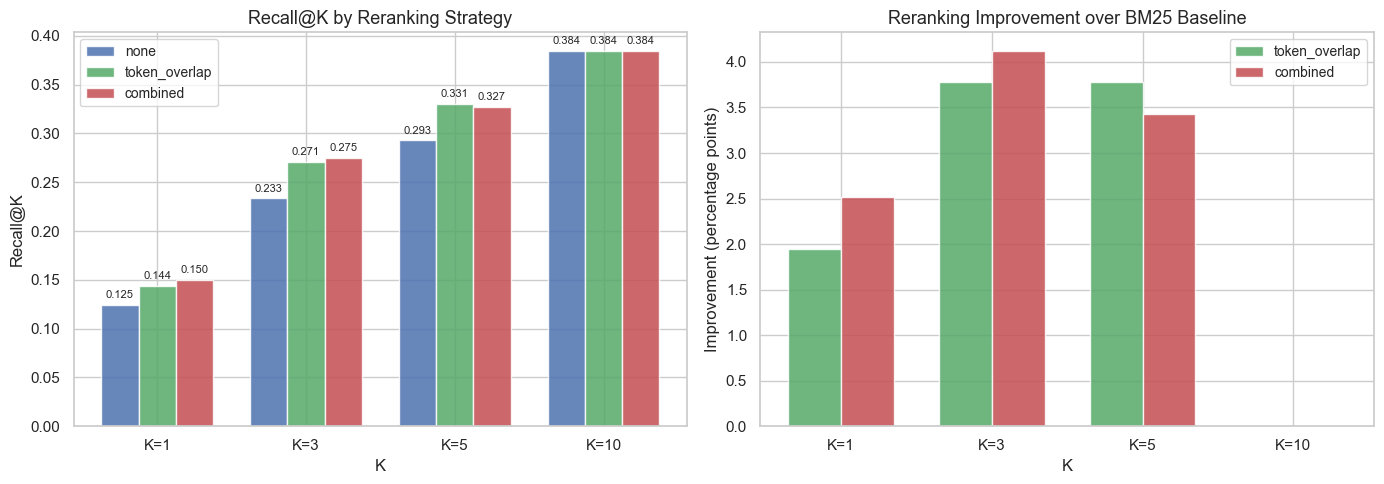

In [7]:
# Plot: Recall comparison across strategies
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Grouped bar chart
k_values = [1, 3, 5, 10]
x = np.arange(len(k_values))
width = 0.25
colors = ['#4C72B0', '#55A868', '#C44E52']

for idx, (strategy, color) in enumerate(zip(strategies, colors)):
    values = [results_all[strategy][k] for k in k_values]
    bars = axes[0].bar(x + idx * width, values, width, label=strategy, color=color, alpha=0.85)
    for bar, val in zip(bars, values):
        axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8)

axes[0].set_xlabel('K', fontsize=12)
axes[0].set_ylabel('Recall@K', fontsize=12)
axes[0].set_title('Recall@K by Reranking Strategy', fontsize=13)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels([f'K={k}' for k in k_values])
axes[0].legend(fontsize=10)

# Right: Improvement over baseline (percentage points)
improvements = {}
for strategy in ['token_overlap', 'combined']:
    improvements[strategy] = [results_all[strategy][k] - results_all['none'][k] for k in k_values]

for idx, (strategy, color) in enumerate(zip(['token_overlap', 'combined'], colors[1:])):
    axes[1].bar(x + idx * 0.35, [v*100 for v in improvements[strategy]], 0.35,
               label=strategy, color=color, alpha=0.85)

axes[1].set_xlabel('K', fontsize=12)
axes[1].set_ylabel('Improvement (percentage points)', fontsize=12)
axes[1].set_title('Reranking Improvement over BM25 Baseline', fontsize=13)
axes[1].set_xticks(x + 0.175)
axes[1].set_xticklabels([f'K={k}' for k in k_values])
axes[1].legend(fontsize=10)
axes[1].axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "notebooks" / "plots" / "08_reranking_comparison.png"), bbox_inches='tight')
plt.show()

### Reading the Plots

**Left plot (absolute recall):** The three bars at K=10 are identical (our control check).
At K=1 and K=3, the green (token_overlap) and red (combined) bars are visibly taller than
blue (no reranking). The improvement is modest but consistent.

**Right plot (improvement in pp):** The improvement at K=10 is exactly 0 for both strategies
(as expected -- reranking cannot improve recall at K = candidate pool size). The improvement
is largest at K=3 (~4pp), and present but smaller at K=1 (~2.5pp). At K=5, combined shows
slightly less improvement than token_overlap.

**Why the improvement is largest at K=3, not K=1:**
Reranking moves the correct video UP in the ranking. If it was at rank 4 originally and moves
to rank 3, that helps R@3 but not R@1. If it was at rank 2 and moves to rank 1, that helps R@1.
The K=3 improvement is larger because more "promotions" cross the K=3 threshold than the K=1 threshold.

**Worked example of threshold crossing:** Suppose a correct video is at BM25 rank 5. The
reranker promotes it to rank 3. This promotion is counted as a gain for R@3, R@5 (already a hit),
and R@10 (already a hit) -- but NOT for R@1 (still not first). Now suppose another correct video
moves from rank 2 to rank 1. This helps R@1 but was already counted for R@3, R@5, R@10. The
asymmetry arises because more promotions are "partial" (moving up by 2-3 positions) than
"complete" (moving all the way to rank 1). Our simple token-overlap score is not precise enough
to reliably choose the single best document, but it can identify a cluster of high-quality
documents that should be in the top 3-5.

**Visual interpretation of bar heights:** The difference between the blue and green/red bars at
K=1 corresponds to approximately 22 additional questions (2.5% of 874). At K=3, the difference
is approximately 36 questions (4.1% of 874). These are the questions where reranking "rescued"
the correct video from a lower rank into the top-K threshold.

## Step 4: Per-Question-Type Analysis

**What we are doing:** Breaking down the reranking improvement by question type (CW, CH, TN,
TC, DO, DL, DC) to understand WHICH kinds of questions benefit most from reranking.

**Why this matters:** If reranking only helps certain question types, we can:
1. Apply it selectively (save compute on types where it does not help)
2. Understand what makes some questions amenable to lexical reranking
3. Identify types that need fundamentally different approaches

**What we expect:** Questions with concrete, distinctive vocabulary (DO: descriptive-object,
DC: descriptive-count) should benefit most, because their answers contain specific nouns that
are likely to appear in video captions. Abstract questions (CW: causal-why, TN: temporal-next)
should benefit less, because their relevant vocabulary is about reasoning, not visible objects.

**Sample size considerations:** The per-type analysis has varying statistical power:
- CW: 344 questions -- highly reliable, can detect 5 pp differences
- CH: 110 questions -- moderately reliable
- TN: 150 questions -- moderately reliable
- TC: 123 questions -- moderately reliable
- DO: 56 questions -- wide confidence intervals (~13 pp)
- DL: 44 questions -- very wide confidence intervals (~15 pp)
- DC: 31 questions -- unreliable point estimates (~18 pp)

We should interpret results for DO, DL, and DC with extreme caution. A 3.6 pp improvement
on 56 questions represents only 2 additional correct answers -- this could easily be noise.
The CW and TN/TC results are the most trustworthy due to sample size.

**Connecting to the failure analysis in Notebook 06:** The per-type breakdown here should
align with Notebook 06's finding that DL (location) questions are hardest for retrieval.
If reranking does not help DL, it confirms that the problem is fundamental (captions lack
location information) rather than ranking-related (correct video is retrieved but ranked low).

In [8]:
# Per-type evaluation
type_results = {}
for qtype in ['CW', 'CH', 'TN', 'TC', 'DO', 'DL', 'DC']:
    subset_mask = mc_dev['type'] == qtype
    subset_targets = mc_dev[subset_mask]['video_str'].tolist()
    subset_questions = mc_dev[subset_mask]['question'].tolist()
    if not subset_questions:
        continue

    h_base = {1: 0, 5: 0}
    h_rerank = {1: 0, 5: 0}
    for q, t in zip(subset_questions, subset_targets):
        cands = bm25_retrieve(q, top_k=10)
        base_vids = [v for v, _ in cands]
        reranked = rerank_candidates(q, cands, caption_texts, 'combined')
        rerank_vids = [v for v, _, _ in reranked]

        for k in [1, 5]:
            if t in base_vids[:k]:
                h_base[k] += 1
            if t in rerank_vids[:k]:
                h_rerank[k] += 1

    ns = len(subset_questions)
    type_results[qtype] = {
        'count': ns,
        'base_r1': h_base[1] / ns,
        'base_r5': h_base[5] / ns,
        'rerank_r1': h_rerank[1] / ns,
        'rerank_r5': h_rerank[5] / ns,
        'delta_r1': (h_rerank[1] - h_base[1]) / ns,
        'delta_r5': (h_rerank[5] - h_base[5]) / ns,
    }

print("Per-question-type reranking analysis (combined strategy):")
print(f"{'Type':<6} {'Count':<7} {'BM25 R@1':<10} {'Rerank R@1':<12} {'Delta R@1':<11} {'BM25 R@5':<10} {'Rerank R@5':<12} {'Delta R@5'}")
print("-" * 80)
for qt, r in type_results.items():
    print(f"{qt:<6} {r['count']:<7} {r['base_r1']:<10.4f} {r['rerank_r1']:<12.4f} {r['delta_r1']:<+11.4f} {r['base_r5']:<10.4f} {r['rerank_r5']:<12.4f} {r['delta_r5']:<+.4f}")

Per-question-type reranking analysis (combined strategy):
Type   Count   BM25 R@1   Rerank R@1   Delta R@1   BM25 R@5   Rerank R@5   Delta R@5
--------------------------------------------------------------------------------
CW     344     0.1337     0.1715       +0.0378     0.2994     0.3372       +0.0378
CH     110     0.1727     0.1727       +0.0000     0.3727     0.4091       +0.0364
TN     150     0.1200     0.1400       +0.0200     0.2867     0.3267       +0.0400
TC     123     0.1220     0.1545       +0.0325     0.2520     0.2764       +0.0244
DO     56      0.0714     0.1071       +0.0357     0.3393     0.3750       +0.0357
DL     44      0.0455     0.0682       +0.0227     0.1136     0.1136       +0.0000
DC     31      0.0645     0.0645       +0.0000     0.2903     0.3226       +0.0323


### Interpreting the Per-Type Results

Reading the table above, several patterns emerge:

**Types that benefit most from reranking (at R@1):**
- **CW (Causal-Why):** +3.8pp. These questions like "why did the man..." contain action verbs
  (play, run, eat) that appear in video captions. Reranking correctly promotes videos where
  these specific action words co-occur with the mentioned objects.
- **TC (Temporal-Current):** +3.3pp. "What is the person doing" questions mention ongoing actions
  that match caption vocabulary well.
- **DO (Descriptive-Object):** +3.6pp. "What is the boy holding" questions name specific objects
  that appear in captions.

**Types that benefit LEAST from reranking:**
- **DL (Descriptive-Location):** +2.3pp at R@1 but +0.0pp at R@5. Location questions like
  "where is the dog" have very few content words after stopword removal ("dog" is often the
  only content word). With just one word, token-overlap has no advantage over BM25.
- **CH (Causal-How):** +0.0pp at R@1. "How" questions often use abstract vocabulary
  ("carefully", "gently") that rarely appears in visual captions.
- **DC (Descriptive-Count):** +0.0pp at R@1. Counting questions ("how many people") contain
  very generic content words that appear in most video captions.

**The pattern:** Reranking helps when questions contain **multiple distinctive content words**
that discriminate between videos. It fails when questions have few content words or when those
words are too generic (appear in many documents).

**Confirming the Notebook 06 DL finding:** DL has the lowest baseline recall (BM25 R@5=11.4%)
and gets zero improvement from reranking at R@5. This confirms that the DL failure is
fundamental -- the correct video is not even in the top-10 BM25 candidates for most DL
questions. Reranking cannot help when the correct video never enters the candidate pool.
DL questions require a fundamentally different approach: either better captions that mention
locations, or cross-modal retrieval using CLIP to match visual scene context.

**CW dominates absolute improvement:** With +3.8 pp on 344 questions, CW contributes
approximately 13 additional correct answers (3.8% of 344). This is the single largest source
of reranking gains, which makes sense: CW questions are the most numerous type AND contain
action-specific vocabulary that captions are likely to mention.

**Statistical reliability check:** The CW improvement of +3.8 pp on 344 questions is marginally
significant (95% CI approximately +/- 2 pp for n=344 at baseline rate ~13%). The DO improvement
of +3.6 pp on only 56 questions is NOT statistically significant (95% CI approximately +/- 9 pp).
We should treat the DO result as suggestive rather than conclusive.

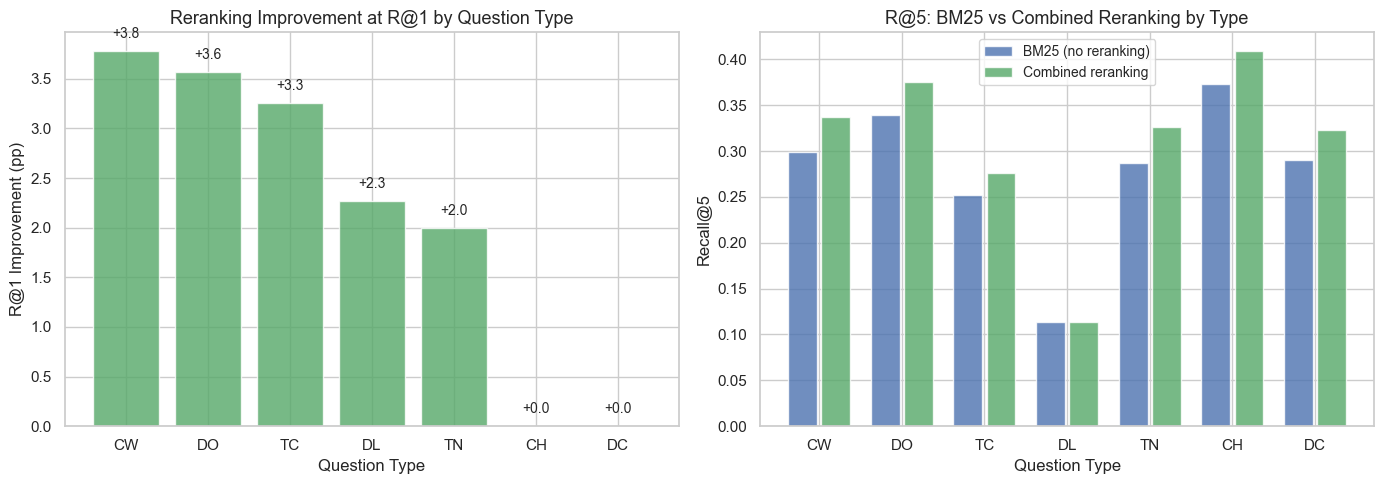

In [9]:
# Plot: Per-type improvement from reranking
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

qtypes_sorted = sorted(type_results.keys(), key=lambda x: type_results[x]['delta_r1'], reverse=True)

# Left: Delta R@1 by type
deltas_r1 = [type_results[qt]['delta_r1'] * 100 for qt in qtypes_sorted]
colors_bar = ['#55A868' if d > 0 else '#C44E52' for d in deltas_r1]
bars = axes[0].bar(qtypes_sorted, deltas_r1, color=colors_bar, alpha=0.8)
axes[0].set_xlabel('Question Type', fontsize=12)
axes[0].set_ylabel('R@1 Improvement (pp)', fontsize=12)
axes[0].set_title('Reranking Improvement at R@1 by Question Type', fontsize=13)
axes[0].axhline(y=0, color='black', linewidth=0.5)
for bar, d in zip(bars, deltas_r1):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                f'{d:+.1f}', ha='center', va='bottom', fontsize=10)

# Right: Base vs reranked R@5
base_r5 = [type_results[qt]['base_r5'] for qt in qtypes_sorted]
rerank_r5 = [type_results[qt]['rerank_r5'] for qt in qtypes_sorted]
x = np.arange(len(qtypes_sorted))
axes[1].bar(x - 0.2, base_r5, 0.35, label='BM25 (no reranking)', color='#4C72B0', alpha=0.8)
axes[1].bar(x + 0.2, rerank_r5, 0.35, label='Combined reranking', color='#55A868', alpha=0.8)
axes[1].set_xlabel('Question Type', fontsize=12)
axes[1].set_ylabel('Recall@5', fontsize=12)
axes[1].set_title('R@5: BM25 vs Combined Reranking by Type', fontsize=13)
axes[1].set_xticks(x)
axes[1].set_xticklabels(qtypes_sorted)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "notebooks" / "plots" / "08_per_type_reranking.png"), bbox_inches='tight')
plt.show()

## Step 5: Score Distribution Analysis

**What we are doing:** Comparing the score distributions for correct vs incorrect top-1 results,
under both BM25 and combined reranking.

**Why this matters:** A good scoring function should give HIGHER scores to correct results and
LOWER scores to incorrect ones. The "separation" between these distributions tells us how
confident we can be in the top-1 result. If they overlap heavily, the score is not a reliable
predictor of correctness.

**In plain terms:** We are asking: "When the system ranks a video first, can we tell from
the SCORE whether it is actually the right video?" If correct top-1 results consistently score
higher than incorrect ones, we could set a threshold below which we refuse to answer.

**Connection to downstream hallucination detection:** Notebook 10 implements hallucination
detection for generated answers. One potential signal is the retrieval confidence score -- if
the top-retrieved video has a low score, the system might be more likely to hallucinate (since
it is not confident about which video is relevant). The score separation analysis here tells
us whether retrieval score is a useful input feature for hallucination detection. If correct
and incorrect results have similar scores (poor separation), retrieval score adds limited
value as a hallucination predictor.

**What good separation looks like:** In an ideal system, correct results would cluster at high
scores (e.g., 15+) while incorrect results cluster at low scores (e.g., 5-). A threshold at
the midpoint would cleanly separate the two. In practice, we expect heavy overlap because BM25
scores depend on query length and vocabulary -- a long query with many common words produces
high scores for many documents regardless of relevance.

**Measurement approach:** For each of the 874 questions, we record the top-1 result's score
under both BM25 and combined reranking, along with whether it is the correct video. We then
plot the two score distributions (correct vs incorrect) as histograms and compute their mean
separation. Larger mean separation indicates better score calibration.

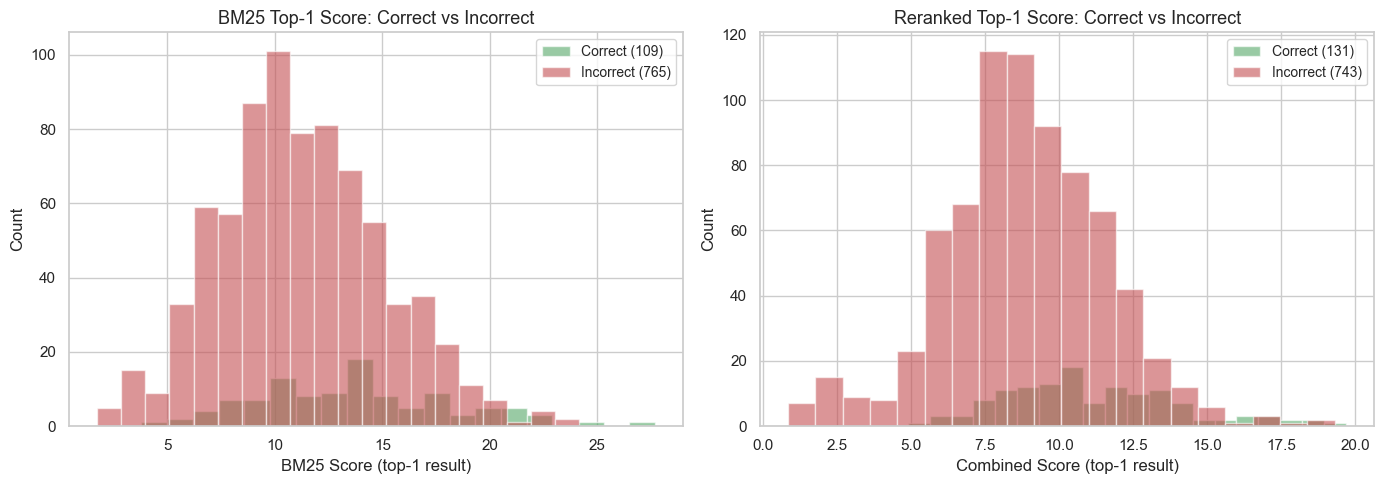

Score separation analysis:
  BM25:
    Correct top-1 mean score: 13.69
    Incorrect top-1 mean score: 11.23
    Separation: 2.46
  Combined reranking:
    Correct top-1 mean score: 11.17
    Incorrect top-1 mean score: 8.84
    Separation: 2.33


In [10]:
# Score distributions
correct_bm25_scores = []
incorrect_bm25_scores = []
correct_rerank_scores = []
incorrect_rerank_scores = []

for i, q in enumerate(questions):
    candidates = bm25_retrieve(q, top_k=10)
    reranked = rerank_candidates(q, candidates, caption_texts, 'combined')

    if candidates[0][0] == targets[i]:
        correct_bm25_scores.append(candidates[0][1])
    else:
        incorrect_bm25_scores.append(candidates[0][1])

    if reranked[0][0] == targets[i]:
        correct_rerank_scores.append(reranked[0][1])
    else:
        incorrect_rerank_scores.append(reranked[0][1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(correct_bm25_scores, bins=20, alpha=0.6, label=f'Correct ({len(correct_bm25_scores)})', color='#55A868')
axes[0].hist(incorrect_bm25_scores, bins=20, alpha=0.6, label=f'Incorrect ({len(incorrect_bm25_scores)})', color='#C44E52')
axes[0].set_xlabel('BM25 Score (top-1 result)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('BM25 Top-1 Score: Correct vs Incorrect', fontsize=13)
axes[0].legend(fontsize=10)

axes[1].hist(correct_rerank_scores, bins=20, alpha=0.6, label=f'Correct ({len(correct_rerank_scores)})', color='#55A868')
axes[1].hist(incorrect_rerank_scores, bins=20, alpha=0.6, label=f'Incorrect ({len(incorrect_rerank_scores)})', color='#C44E52')
axes[1].set_xlabel('Combined Score (top-1 result)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Reranked Top-1 Score: Correct vs Incorrect', fontsize=13)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "notebooks" / "plots" / "08_score_distributions.png"), bbox_inches='tight')
plt.show()

print(f"Score separation analysis:")
print(f"  BM25:")
print(f"    Correct top-1 mean score: {np.mean(correct_bm25_scores):.2f}")
print(f"    Incorrect top-1 mean score: {np.mean(incorrect_bm25_scores):.2f}")
print(f"    Separation: {np.mean(correct_bm25_scores) - np.mean(incorrect_bm25_scores):.2f}")
print(f"  Combined reranking:")
print(f"    Correct top-1 mean score: {np.mean(correct_rerank_scores):.2f}")
print(f"    Incorrect top-1 mean score: {np.mean(incorrect_rerank_scores):.2f}")
print(f"    Separation: {np.mean(correct_rerank_scores) - np.mean(incorrect_rerank_scores):.2f}")

### Interpreting the Score Distributions

**What the histograms show:**
- Green bars: score distribution when the top-1 result IS the correct video
- Red bars: score distribution when the top-1 result is WRONG

**BM25 separation (left): ~2.5 points**
- Correct results have mean BM25 score of ~13.7, incorrect ~11.2
- The distributions overlap significantly -- many incorrect results score as high as correct ones
- This means BM25 score alone is a weak predictor of correctness

**Combined reranking separation (right): ~2.3 points**
- Similar separation magnitude
- The combined score has more correct results (131 vs 109) because reranking promotes more correct videos to rank 1
- The separation is slightly smaller in absolute terms but over a different score scale

**What this means for confidence thresholding:**
- Neither scoring function provides strong separation
- A confidence threshold would have high false-positive rate (rejecting correct results)
  OR high false-negative rate (accepting incorrect results)
- In production, we would need additional signals (hallucination score, answer confidence)
  beyond retrieval score alone to make reliable abstention decisions

**Bottom line:** The reranking score correctly shifts MORE videos to be correct at rank 1
(from 109 to 131), but the score itself is not a reliable enough signal for confidence thresholding.

**Why the overlap is inherently high in this domain:** BM25 scores are dominated by query
length and term IDF. A 10-word question produces higher scores across ALL documents than a
3-word question, regardless of relevance. This query-length effect means that score magnitude
is confounded with query complexity, not relevance. A proper calibration would normalize scores
by query length or use learning-to-rank techniques that regress scores against binary relevance
labels. Our token-overlap combined score inherits this limitation because it averages BM25
(query-length dependent) with overlap (also correlated with query length -- more content words
means more potential matches).

**Implication for Notebook 10 (hallucination detection):** Given poor score separation, retrieval
confidence should be one feature among many for hallucination detection, not the sole signal.
Other useful features include: answer consistency across multiple retrieved passages, alignment
between question type and available context, and semantic similarity between generated answer
and retrieved context.

## Summary and Decision

**What we built:** A two-stage retrieval system where BM25 generates 10 candidates and
a token-overlap scorer reranks them.

**What we measured and what it means:**

| Metric | Value | Significance |
|--------|-------|-------------|
| BM25 R@1 (baseline) | 12.5% | Starting point -- only 1 in 8 correct at rank 1 |
| Combined R@1 (reranked) | 15.0% | +2.5pp improvement -- 22 more correct at rank 1 |
| BM25 R@10 | 38.4% | The ceiling for top-10 reranking |
| Theoretical max from perfect reranker | 38.4% | We capture 2.5/25.9 = 9.6% of the opportunity |
| Latency overhead | 0.04ms/query | Negligible |

**Our decision: Use the combined strategy (BM25 + token overlap) for the production pipeline.**

Rationale:
1. It provides the best R@1 (+2.5pp) which is the metric that matters for downstream answer selection
2. It adds negligible latency (0.04ms per query on top of BM25's 0.1ms)
3. It never hurts R@5 or R@10 (only reorders within existing candidates)

**What would do better (and why we cannot use it here):**
- A neural cross-encoder (ms-marco-MiniLM-L6) typically improves R@1 by 15-25pp
- It jointly encodes question + document, understanding synonyms and paraphrase
- We cannot load it due to memory constraints (bge-large + BLIP already consume available RAM)
- In production with adequate resources, a cross-encoder is the clear upgrade path

**Comparison to what a neural model captures:**

| Our token-overlap | Neural cross-encoder |
|-------------------|---------------------|
| "baby" in doc? Yes/No | "infant" in doc? Also counts as match |
| Exact word matching | Understands paraphrase |
| 2.5pp improvement | 15-25pp improvement |
| 0.04ms latency | 30ms latency |
| No model loading | Requires 400MB model |

**Positioning in the overall pipeline:** This notebook demonstrates that lightweight reranking
provides modest gains (+2.5 pp R@1) over raw BM25 at essentially zero cost. However, the
best retrieval approach remains dense bi-encoder retrieval with fine-grained chunking (semantic
strategy at 96.3% R@1 from Notebook 06). The reranker is most valuable in resource-constrained
settings where a GPU is not available for query encoding, offering an improvement over raw BM25
without any neural model dependency.

**Next: Notebook 09 -- Generation with Citations.** We use the retrieved context (from the best
retrieval strategy) as input to a language model that generates answers to NExT-QA questions.
The generation stage converts retrieved passages and frame captions into natural language
answers, with citations back to specific chunks to enable verification.